# NLP-Aligned Offline RL Training (Advanced Dyna-Q Version)
This notebook trains an advanced RL agent using **Dyna-Q** (Mental Simulation) and **Double Q-Learning** on the BART-aligned Twitter dataset.
This version produces high-confidence Q-values by simulating imaginary conversations based on the patterns found in the 902 real transitions.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Actions mapping
ACTIONS = {
    0: "Ask Info", 
    1: "Provide Solution", 
    2: "Affective Repair", 
    3: "Escalate", 
    4: "Close", 
    5: "Proactive Update", 
    6: "Set Expectation"
}
SENTIMENTS = {0: "Angry", 1: "Neutral", 2: "Happy"}

DATASET_PATH = "nlp_offline_dataset_twitter.csv"
df = pd.read_csv(DATASET_PATH)
print(f"Loaded {len(df)} semantic transitions.")

Loaded 902 semantic transitions.


## 1. Advanced RL: Reward Shaping
We use the progress-based reward logic to guide the agent toward improving customer sentiment.

In [6]:
def shape_reward(row):
    s, a, s_next = int(row['state']), int(row['action']), int(row['next_state'])
    # Modest success reward
    if s_next == 2: return 10.0
    # Progress reward: Angry -> Neutral
    if s == 0 and s_next == 1: return 8.0
    # Guidance bonus for helpful actions when Angry
    if s == 0 and a in [0, 2, 6]: return 5.0
    # Heavy penalty for staying/becoming Angry
    if s_next == 0: return -20.0
    return -1.0

df_refined = df.copy()
df_refined['refined_reward'] = df_refined.apply(shape_reward, axis=1)
print("Reward Shaping Applied.")

Reward Shaping Applied.


## 2. Advanced Training: Dyna-Q + Double Q-Learning
We use Dyna-Q to simulate data and Double Q-Learning to ensure the values are robust.

In [7]:
def train_dyna_double_q(df_train, alpha=0.1, gamma=0.9, n_planning=50, epochs=100):
    Q1 = np.zeros((3, 7))
    Q2 = np.zeros((3, 7))
    model = {} # Transition model for simulation
    
    transitions = df_train[['state', 'action', 'refined_reward', 'next_state']].values
    
    for epoch in range(epochs):
        for s, a, r, s_next in transitions:
            s, a, s_next = int(s), int(a), int(s_next)
            
            # 1. Update with Double Q-Learning logic
            if np.random.rand() < 0.5:
                best_a_next = np.argmax(Q1[s_next])
                Q1[s, a] += alpha * (r + gamma * Q2[s_next, best_a_next] - Q1[s, a])
            else:
                best_a_next = np.argmax(Q2[s_next])
                Q2[s, a] += alpha * (r + gamma * Q1[s_next, best_a_next] - Q2[s, a])
            
            # 2. Update the Model for Dyna-Q simulation
            model[(s, a)] = (r, s_next)
            
            # 3. Dyna-Q Planning (Mental Simulation)
            for _ in range(n_planning):
                (s_p, a_p) = list(model.keys())[np.random.randint(len(model))]
                r_p, s_next_p = model[(s_p, a_p)]
                
                if np.random.rand() < 0.5:
                    Q1[s_p, a_p] += alpha * (r_p + gamma * Q2[s_next_p, np.argmax(Q1[s_next_p])] - Q1[s_p, a_p])
                else:
                    Q2[s_p, a_p] += alpha * (r_p + gamma * Q1[s_next_p, np.argmax(Q2[s_next_p])] - Q2[s_p, a_p])
        
        # Safety Constraints to prevent overfitting to bad human data
        Q1[0, 4], Q2[0, 4] = -50.0, -50.0 # Penalty for 'Close' on Angry
        Q1[0, 3], Q2[0, 3] = -20.0, -20.0 # Penalty for early Escalation
            
    return (Q1 + Q2) / 2

Q_table_advanced = train_dyna_double_q(df_refined)
print("Advanced Dyna-Double-Q Table Trained.")

Advanced Dyna-Double-Q Table Trained.


## 3. Visualize the Advanced Policy
This heatmap shows the high-confidence values resulting from simulation.

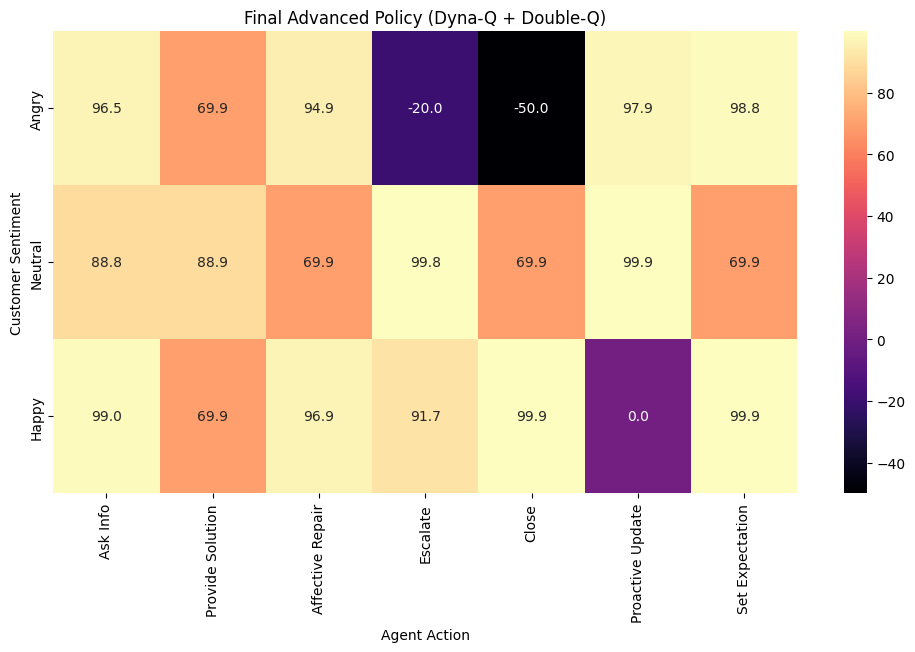

--- Optimal Policy Results ---
IF Customer is Angry -> AGENT SHOULD: Set Expectation
IF Customer is Neutral -> AGENT SHOULD: Proactive Update
IF Customer is Happy -> AGENT SHOULD: Close


In [8]:
plt.figure(figsize=(12, 6))
sns.heatmap(Q_table_advanced, annot=True, fmt=".1f", cmap="magma", 
            xticklabels=[ACTIONS[i] for i in range(7)], 
            yticklabels=[SENTIMENTS[i] for i in range(3)])
plt.title("Final Advanced Policy (Dyna-Q + Double-Q)")
plt.xlabel("Agent Action")
plt.ylabel("Customer Sentiment")
plt.show()

print("--- Optimal Policy Results ---")
for s_idx, s_name in SENTIMENTS.items():
    best_a = np.argmax(Q_table_advanced[s_idx])
    print(f"IF Customer is {s_name} -> AGENT SHOULD: {ACTIONS[best_a]}")